<a href="https://colab.research.google.com/github/jaxa4ever-code/week12_lab/blob/main/Gradient_Descent_and_Polynomial_Regression_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gradient Descent and Polynomial Regression

## Overview
In this lab, you will learn how to implement and compare three core optimization strategies used in machine learning:

- **Batch Gradient Descent (BGD)**
- **Stochastic Gradient Descent (SGD)**
- **Mini-Batch Gradient Descent (MBGD)**

You will first study the underlying mathematics and implement these methods **from scratch with NumPy**.
Then you will apply them to **polynomial regression**, analyze their behavior, and complete hands-on exercises.

## Learning Objectives
By the end of this lab, you should be able to:

1. Explain how gradient descent minimizes a cost function.
2. Derive and implement update rules for BGD, SGD, and MBGD.
3. Build polynomial features for nonlinear curve fitting.
4. Compare optimization methods in terms of speed, stability, and final performance.
5. Critically evaluate hyperparameters such as learning rate and batch size.

In [1]:
# =============================
# Imports and visual settings
# =============================
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1) Gradient Descent: Concept and Mathematics

### Why Gradient Descent?
For many machine learning models, we define a loss (or cost) function and want to find model parameters that minimize it.
Gradient descent is an iterative optimization algorithm that updates parameters in the direction of the **negative gradient** of the loss.

### Linear Model Form
We use a hypothesis:

$$
\hat{y} = X\theta
$$

where:
- $X \in \mathbb{R}^{m \times n}$ is the design matrix,
- $\theta \in \mathbb{R}^{n \times 1}$ are model parameters,
- $\hat{y} \in \mathbb{R}^{m \times 1}$ are predictions.

### Cost Function (Mean Squared Error)

$$
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^2
$$

In matrix form:

$$
J(\theta) = \frac{1}{2m}(X\theta - y)^T(X\theta - y)
$$

### Gradient of MSE

$$
\nabla_\theta J(\theta) = \frac{1}{m}X^T(X\theta - y)
$$

### Update Rule

$$
\theta := \theta - \eta \nabla_\theta J(\theta)
$$

where $\eta$ is the learning rate.

---

## Three Variants

1. **Batch GD**: Uses all training examples each update.
   $$
   \theta := \theta - \eta \cdot \frac{1}{m}X^T(X\theta - y)
   $$

2. **Stochastic GD (SGD)**: Uses one sample at a time.
   $$
   \theta := \theta - \eta \cdot x_i^T(x_i\theta - y_i)
   $$

3. **Mini-Batch GD**: Uses a small batch $B$ each update.
   $$
   \theta := \theta - \eta \cdot \frac{1}{|B|}X_B^T(X_B\theta - y_B)
   $$

Trade-off intuition:
- Batch: stable but can be slow per update.
- SGD: fast, noisy updates.
- Mini-Batch: balanced and widely used in practice.

In [2]:
class GradientDescentRegressor:
    """
    Linear regressor optimized using batch, stochastic, or mini-batch GD.
    """
    def __init__(self, method="batch", lr=0.01, epochs=200, batch_size=32, random_state=42):
        self.method = method
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.theta = None
        self.loss_history = []
        self.training_time = None

    def _compute_gradient(self, X, y):
        """Gradient of MSE cost with respect to theta."""
        m = X.shape[0]
        errors = X @ self.theta - y
        grad = (X.T @ errors) / m
        return grad

    def fit(self, X, y):
        """Train model parameters using selected GD method."""
        rng = np.random.default_rng(self.random_state)
        m, n = X.shape
        self.theta = np.zeros((n, 1))
        self.loss_history = []

        start = time.perf_counter()

        for epoch in range(self.epochs):
            if self.method == "batch":
                grad = self._compute_gradient(X, y)
                self.theta -= self.lr * grad

            elif self.method == "sgd":
                # Shuffle indices each epoch for better stochastic behavior.
                indices = rng.permutation(m)
                for i in indices:
                    Xi = X[i:i+1]
                    yi = y[i:i+1]
                    grad = Xi.T @ (Xi @ self.theta - yi)  # batch size is 1
                    self.theta -= self.lr * grad

            elif self.method == "mini-batch":
                indices = rng.permutation(m)
                for start_idx in range(0, m, self.batch_size):
                    batch_idx = indices[start_idx:start_idx + self.batch_size]
                    Xb = X[batch_idx]
                    yb = y[batch_idx]
                    grad = (Xb.T @ (Xb @ self.theta - yb)) / Xb.shape[0]
                    self.theta -= self.lr * grad

            else:
                raise ValueError("method must be 'batch', 'sgd', or 'mini-batch'")

            # Track full-dataset loss after each epoch.
            y_pred_epoch = X @ self.theta
            epoch_loss = mean_squared_error(y, y_pred_epoch)
            self.loss_history.append(epoch_loss)

        end = time.perf_counter()
        self.training_time = end - start
        return self

    def predict(self, X):
        """Predict targets for input matrix X."""
        return X @ self.theta

## 2) Simple Example: Compare BGD, SGD, and MBGD

We start with a simple linear dataset to compare convergence behavior of the three methods.

Model: $y = 4 + 3x + \epsilon$

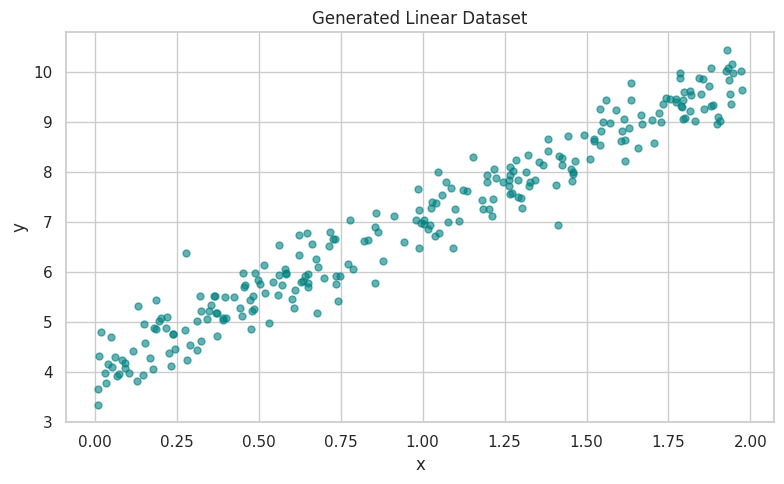

,Method,Final MSE,Training Time (s),Final Theta
0,Batch GD,0.218234,0.037196,"[3.606754282347466, 3.3500936172456846]"
1,SGD,0.156999,0.116461,"[4.072970623899527, 2.9471973098206514]"
2,Mini-Batch GD,0.157060,0.032610,"[4.054809763947758, 2.9712473416164924]"


In [3]:
# Generate synthetic linear data
m = 250
X_raw = 2 * np.random.rand(m, 1)
noise = np.random.randn(m, 1) * 0.4
y = 4 + 3 * X_raw + noise

# Visualize dataset immediately after generation
plt.figure(figsize=(8, 5))
plt.scatter(X_raw, y, alpha=0.6, s=25, color="teal")
plt.title("Generated Linear Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# Add bias term for linear model
X = np.c_[np.ones((X_raw.shape[0], 1)), X_raw]

# Train all three variants
models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=0.08, epochs=50),
    "SGD": GradientDescentRegressor(method="sgd", lr=0.01, epochs=50),
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=0.03, epochs=50, batch_size=16)
}

results_simple = []

for name, model in models.items():
    model.fit(X, y)
    y_pred = model.predict(X)
    results_simple.append({
        "Method": name,
        "Final MSE": mean_squared_error(y, y_pred),
        "Training Time (s)": model.training_time,
        "Final Theta": model.theta.ravel()
    })

simple_results_df = pd.DataFrame(results_simple)
simple_results_df

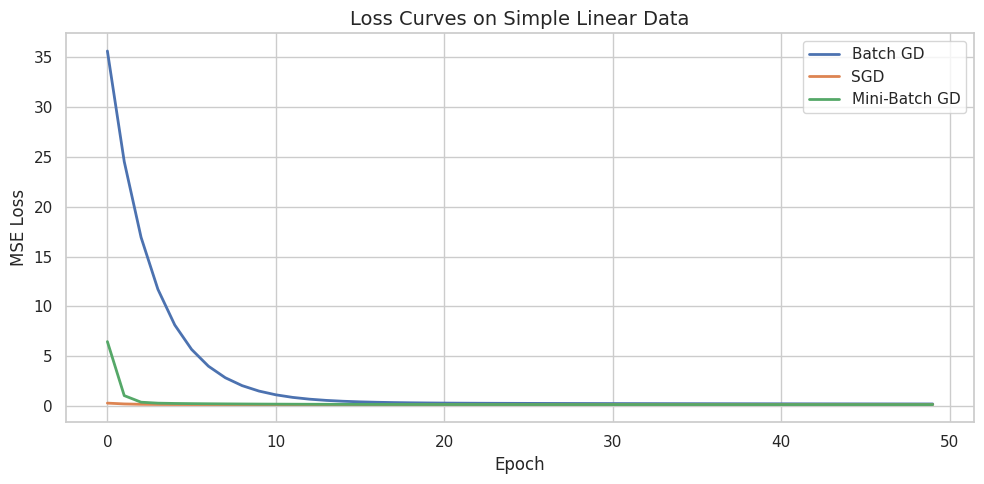

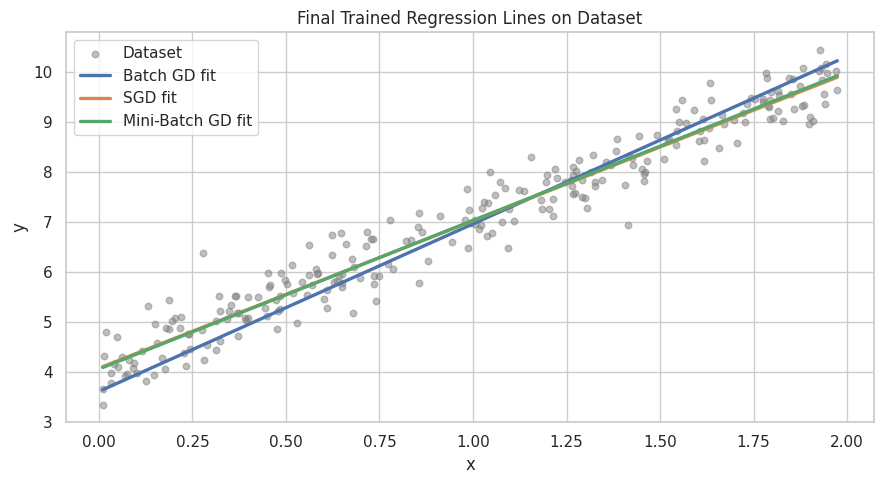

,Method,Final MSE,Training Time (s),Final Theta
1,SGD,0.156999,0.116461,"[4.072970623899527, 2.9471973098206514]"
2,Mini-Batch GD,0.157060,0.032610,"[4.054809763947758, 2.9712473416164924]"
0,Batch GD,0.218234,0.037196,"[3.606754282347466, 3.3500936172456846]"


In [4]:
# Plot loss curves to compare convergence
plt.figure(figsize=(10, 5))
for name, model in models.items():
    plt.plot(model.loss_history, label=name, linewidth=2)

plt.title("Loss Curves on Simple Linear Data", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Visualize final trained regression lines on top of the dataset
x_line = np.linspace(X_raw.min(), X_raw.max(), 300).reshape(-1, 1)
X_line = np.c_[np.ones((x_line.shape[0], 1)), x_line]

plt.figure(figsize=(9, 5))
plt.scatter(X_raw, y, alpha=0.5, s=22, color="gray", label="Dataset")
for name, model in models.items():
    y_line_pred = model.predict(X_line)
    plt.plot(x_line, y_line_pred, linewidth=2.4, label=f"{name} fit")

plt.title("Final Trained Regression Lines on Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

display(simple_results_df.sort_values("Final MSE"))

### Interpretation
- **Batch GD** usually gives smoother convergence because each update uses the full dataset.
- **SGD** often converges quickly at first but exhibits noisier loss curves.
- **Mini-Batch GD** balances stability and computational efficiency.

In practice, mini-batch methods are widely used because they are GPU-friendly and often converge well.

## 3) Polynomial Regression from Scratch

### Why Polynomial Features?
A linear model in the original feature space can only fit straight lines/planes.
If the relationship between $x$ and $y$ is nonlinear, we can map input $x$ to polynomial features:

$$
\phi(x) = [x, x^2, x^3, \dots, x^d]
$$

Then fit a linear model in transformed space:

$$
\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2 + \cdots + \theta_d x^d
$$

This is still linear in parameters $\theta$, so gradient descent applies directly.

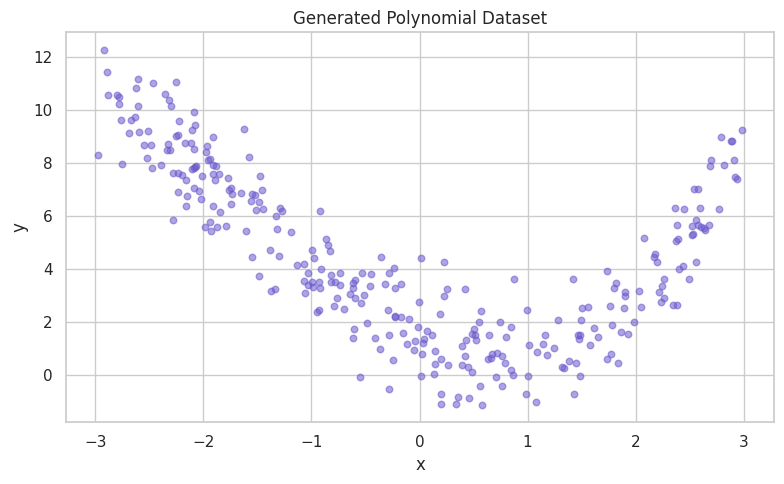

Polynomial data prepared.
Design matrix shape: (300, 4)


In [5]:
# Generate synthetic polynomial data
m_poly = 300
x_poly = np.random.uniform(-3, 3, size=(m_poly, 1))
y_poly = 1.5 - 2.0 * x_poly + 0.9 * (x_poly ** 2) + 0.2 * (x_poly ** 3) + np.random.randn(m_poly, 1) * 1.2

# Visualize dataset immediately after generation
plt.figure(figsize=(8, 5))
plt.scatter(x_poly, y_poly, alpha=0.55, s=22, color="slateblue")
plt.title("Generated Polynomial Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# Create polynomial features up to degree 3 using sklearn
degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly_raw = poly.fit_transform(x_poly)

# Standardize polynomial features for stable GD updates using sklearn
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly_raw)

# Add explicit bias for our from-scratch GD implementation
X_poly_design = np.c_[np.ones((X_poly_scaled.shape[0], 1)), X_poly_scaled]

print("Polynomial data prepared.")
print("Design matrix shape:", X_poly_design.shape)

In [6]:
# Train polynomial regression with all three GD variants
poly_models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=0.05, epochs=250),
    "SGD": GradientDescentRegressor(method="sgd", lr=0.005, epochs=250),
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=0.02, epochs=250, batch_size=32)
}

poly_results = []
for name, model in poly_models.items():
    model.fit(X_poly_design, y_poly)
    y_pred = model.predict(X_poly_design)

    # Convergence criterion example: first epoch where loss <= 1.05 * final loss
    final_loss = model.loss_history[-1]
    threshold = 1.05 * final_loss
    epochs_to_converge = next((i + 1 for i, l in enumerate(model.loss_history) if l <= threshold), model.epochs)

    poly_results.append({
        "Method": name,
        "Final MSE": mean_squared_error(y_poly, y_pred),
        "Epochs to Converge": epochs_to_converge,
        "Training Time (s)": model.training_time
    })

poly_results_df = pd.DataFrame(poly_results)
poly_results_df

,Method,Final MSE,Epochs to Converge,Training Time (s)
0,Batch GD,1.424179,195,0.126019
1,SGD,1.292687,12,0.908306
2,Mini-Batch GD,1.292398,86,0.205980


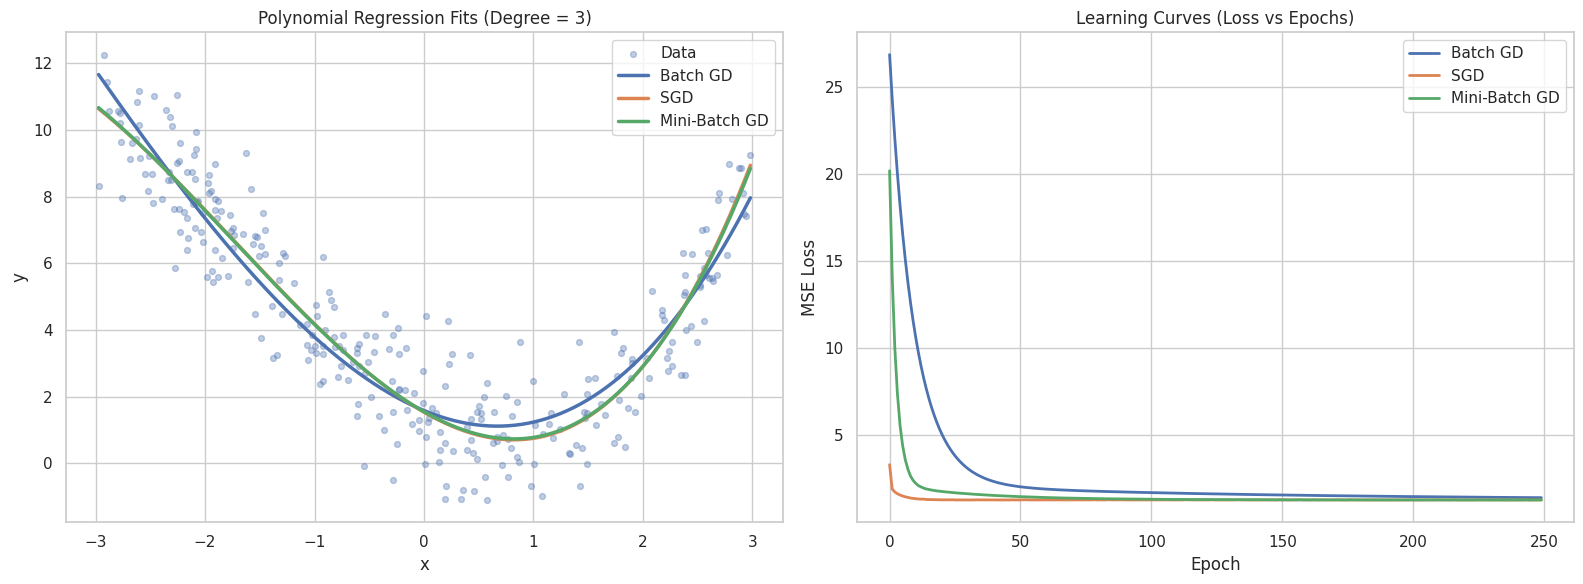

,Method,Final MSE,Epochs to Converge,Training Time (s)
2,Mini-Batch GD,1.292398,86,0.205980
1,SGD,1.292687,12,0.908306
0,Batch GD,1.424179,195,0.126019


In [7]:
# Visualize fitted curves and learning curves
x_grid = np.linspace(x_poly.min(), x_poly.max(), 400).reshape(-1, 1)
X_grid_raw = poly.transform(x_grid)
X_grid_scaled = scaler.transform(X_grid_raw)
X_grid_design = np.c_[np.ones((X_grid_scaled.shape[0], 1)), X_grid_scaled]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: data + fitted curves
axes[0].scatter(x_poly, y_poly, alpha=0.35, s=18, label="Data")
for name, model in poly_models.items():
    y_grid_pred = model.predict(X_grid_design)
    axes[0].plot(x_grid, y_grid_pred, linewidth=2.5, label=name)

axes[0].set_title("Polynomial Regression Fits (Degree = 3)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

# Right: learning curves
for name, model in poly_models.items():
    axes[1].plot(model.loss_history, linewidth=2, label=name)

axes[1].set_title("Learning Curves (Loss vs Epochs)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

display(poly_results_df.sort_values("Final MSE"))

### Observations
- All three methods can fit polynomial regression when features are engineered properly.
- Feature scaling is critical for numerical stability, especially for high-degree polynomial terms.
- SGD may oscillate more due to noisy updates, while Batch GD is smoother.
- Mini-Batch GD often gives a strong practical compromise.

# 4) Lab Exercises (Total: 100 points)

Complete the following tasks. Write clean code, include plots, and explain your findings in markdown.

## Task 1 (25 points)
**Implement Batch Gradient Descent from scratch** for a 4nd-degree polynomial regression on a new synthetic dataset (use different coefficients and noise from tutorial).

### Requirements
- Generate your own dataset.
- Build polynomial features (degree 4).
- Train using Batch GD.
- Plot fitted curve and learning curve.

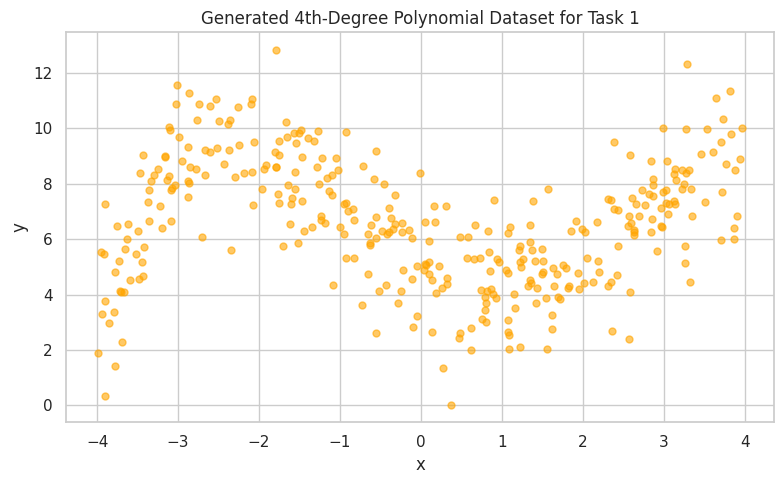

Task 1 polynomial data prepared.
Design matrix shape for Task 1: (350, 5)


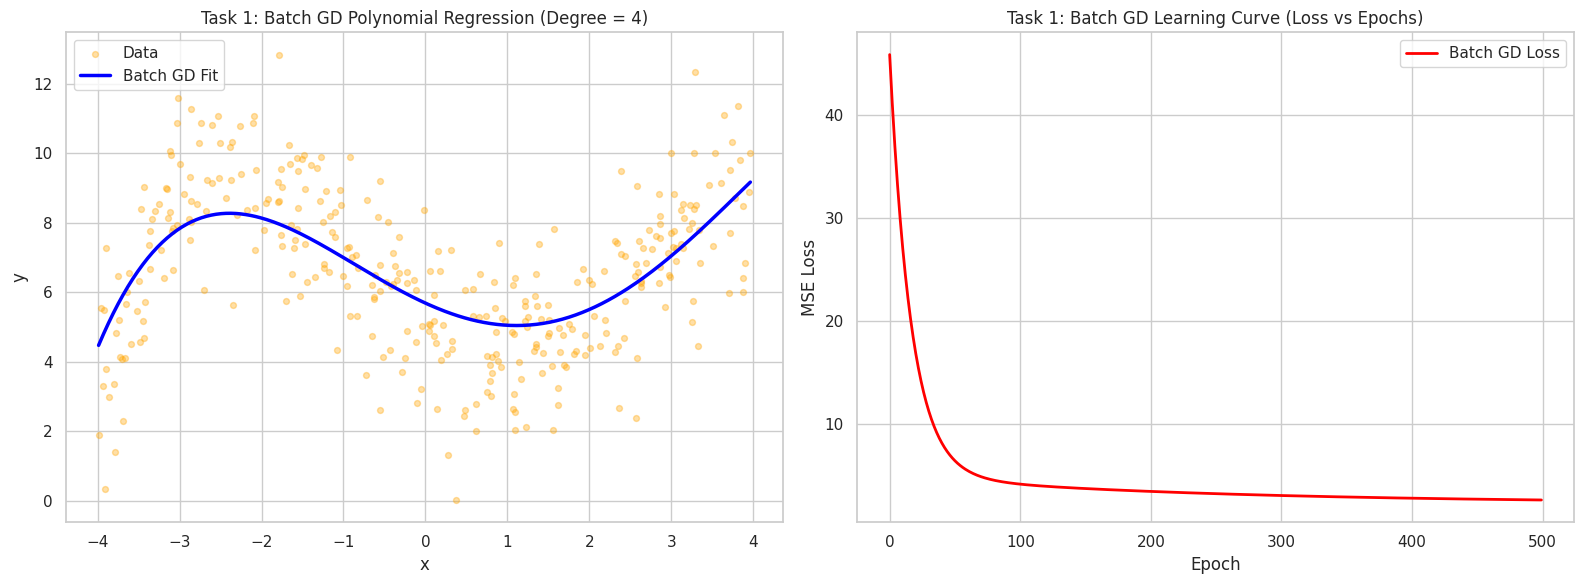

Task 1 Batch GD Final MSE: 2.5875
Task 1 Batch GD Training Time (s): 0.2126


In [9]:
# -----------------------------
# Task 1 starter template
# -----------------------------
# Generate a new synthetic 4th-degree polynomial dataset with different coefficients/noise.
# Example target form: y = a + b*x + c*x^2 + d*x^3 + e*x^4 + noise

m_t1 = 350 # Number of samples
x_t1 = np.random.uniform(-4, 4, size=(m_t1, 1))

# Define coefficients for a 4th-degree polynomial
coeff_a = 5.0
coeff_b = -1.5
coeff_c = 0.8
coeff_d = 0.15
coeff_e = -0.05

y_t1 = coeff_a + coeff_b * x_t1 + coeff_c * (x_t1 ** 2) + coeff_d * (x_t1 ** 3) + coeff_e * (x_t1 ** 4) + np.random.randn(m_t1, 1) * 1.5

# Visualize the generated dataset
plt.figure(figsize=(8, 5))
plt.scatter(x_t1, y_t1, alpha=0.6, s=25, color="orange")
plt.title("Generated 4th-Degree Polynomial Dataset for Task 1")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

# Build degree-4 polynomial features and standardize using sklearn.
degree_t1 = 4
poly_t1 = PolynomialFeatures(degree=degree_t1, include_bias=False)
X_t1_raw = poly_t1.fit_transform(x_t1)

scaler_t1 = StandardScaler()
X_t1_scaled = scaler_t1.fit_transform(X_t1_raw)

# Add explicit bias for our from-scratch GD implementation
X_t1_design = np.c_[np.ones((X_t1_scaled.shape[0], 1)), X_t1_scaled]

print("Task 1 polynomial data prepared.")
print("Design matrix shape for Task 1:", X_t1_design.shape)

# Train Batch GD.
batch_gd_t1 = GradientDescentRegressor(method="batch", lr=0.03, epochs=500)
batch_gd_t1.fit(X_t1_design, y_t1)

# Plot fitted curve and loss curve.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Prepare grid for plotting the fitted curve
x_grid_t1 = np.linspace(x_t1.min(), x_t1.max(), 400).reshape(-1, 1)
X_grid_raw_t1 = poly_t1.transform(x_grid_t1)
X_grid_scaled_t1 = scaler_t1.transform(X_grid_raw_t1)
X_grid_design_t1 = np.c_[np.ones((X_grid_scaled_t1.shape[0], 1)), X_grid_scaled_t1]

y_grid_pred_t1 = batch_gd_t1.predict(X_grid_design_t1)

# Left: data + fitted curve
axes[0].scatter(x_t1, y_t1, alpha=0.35, s=18, label="Data", color="orange")
axes[0].plot(x_grid_t1, y_grid_pred_t1, linewidth=2.5, label="Batch GD Fit", color="blue")
axes[0].set_title(f"Task 1: Batch GD Polynomial Regression (Degree = {degree_t1})")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()

# Right: learning curve
axes[1].plot(batch_gd_t1.loss_history, linewidth=2, label="Batch GD Loss", color="red")
axes[1].set_title("Task 1: Batch GD Learning Curve (Loss vs Epochs)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Task 1 Batch GD Final MSE: {mean_squared_error(y_t1, batch_gd_t1.predict(X_t1_design)):.4f}")
print(f"Task 1 Batch GD Training Time (s): {batch_gd_t1.training_time:.4f}")

## Task 2 (25 points)
**Implement Stochastic Gradient Descent (SGD)** and tune the learning rate.

### Requirements
- Use one polynomial dataset.
- Try multiple learning rates (e.g., 0.0005, 0.001, 0.005, 0.01).
- Plot loss curves for each learning rate.
- Explain underfitting/divergence/instability if observed.

### Analysis of Learning Rate Effects in SGD

From the plots and results above, we can observe the following effects of different learning rates on SGD:

*   **`lr = 0.0005` (Too Small)**:
    *   **Convergence**: The loss decreases very slowly. The model requires significantly more epochs to approach a good solution. The final MSE might not be as low as with higher learning rates within the same number of epochs, indicating underfitting due to insufficient learning.
    *   **Stability**: The updates are very stable and smooth, as each step is tiny. However, this comes at the cost of speed.

*   **`lr = 0.001` (Moderate)**:
    *   **Convergence**: This learning rate shows a more reasonable convergence speed. The loss decreases steadily and reaches a relatively low MSE within the given epochs.
    *   **Stability**: The loss curve is generally stable, though with some minor oscillations typical of SGD due to its stochastic nature.

*   **`lr = 0.005` (Higher, but still good)**:
    *   **Convergence**: The model converges even faster than with `lr=0.001`, reaching a low MSE in fewer epochs. This is often a good balance between speed and stability.
    *   **Stability**: The loss curve might show slightly more oscillation than with smaller learning rates, but it still maintains a downward trend towards the minimum.

*   **`lr = 0.01` (Too Large)**:
    *   **Convergence**: The loss initially decreases, but then it starts oscillating wildly or even increasing significantly. This indicates that the learning rate is too high, causing the optimization to overshoot the minimum and potentially diverge or oscillate around it without settling.
    *   **Instability/Divergence**: The loss curve is very noisy and erratic. The model struggles to find a stable minimum. If the learning rate were even higher, the loss could quickly explode to `inf` (divergence).

**Conclusion**: Choosing an appropriate learning rate is crucial for SGD. A learning rate that is too small leads to slow convergence (underfitting within a fixed number of epochs), while one that is too large can cause instability or outright divergence. A moderate learning rate often provides the best balance between convergence speed and stability.

Using polynomial dataset with shape: (300, 4)
Training SGD with learning rate: 0.0005
Training SGD with learning rate: 0.001
Training SGD with learning rate: 0.005
Training SGD with learning rate: 0.01


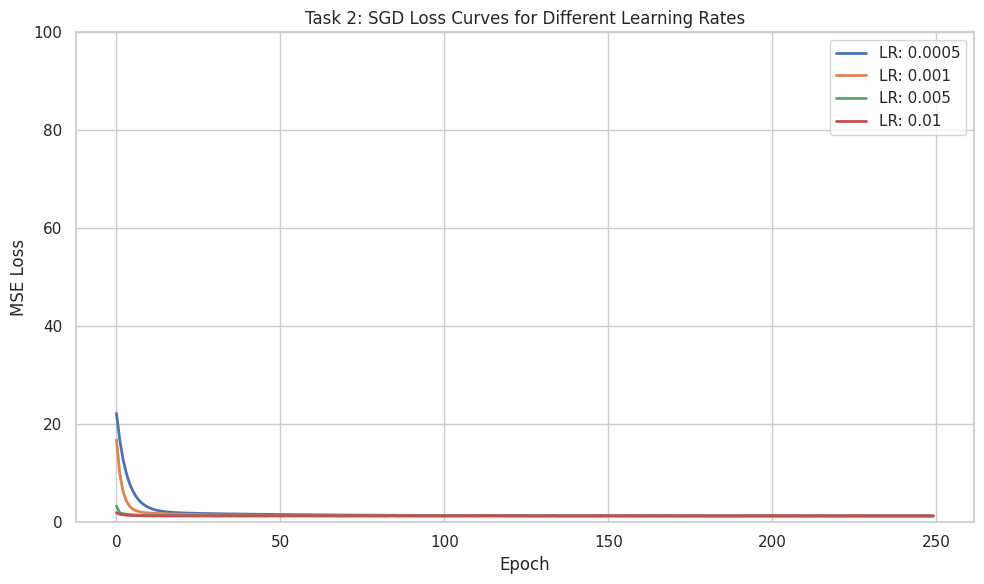

,Learning Rate,Final MSE,Epochs to Converge,Training Time (s)
1,0.0010,1.291670,58,0.658520
2,0.0050,1.292687,12,0.662414
0,0.0005,1.294384,113,0.699765
3,0.0100,1.297112,6,0.665216


In [11]:
# -----------------------------
# Task 2 starter template
# -----------------------------
learning_rates = [0.0005, 0.001, 0.005, 0.01]
sgd_histories = {}
sgd_results = []

# Reuse the polynomial dataset from the tutorial's poly-data-generation cell
# X_poly_design and y_poly are already available from earlier execution.
X_t2 = X_poly_design
y_t2 = y_poly

print(f"Using polynomial dataset with shape: {X_t2.shape}")

for lr in learning_rates:
    print(f"Training SGD with learning rate: {lr}")
    sgd_model = GradientDescentRegressor(method="sgd", lr=lr, epochs=250, random_state=42)
    sgd_model.fit(X_t2, y_t2)
    sgd_histories[lr] = sgd_model.loss_history

    y_pred_t2 = sgd_model.predict(X_t2)
    final_mse = mean_squared_error(y_t2, y_pred_t2)

    # Convergence criterion example: first epoch where loss <= 1.05 * final loss
    final_loss = sgd_model.loss_history[-1]
    threshold = 1.05 * final_loss
    epochs_to_converge = next((i + 1 for i, l in enumerate(sgd_model.loss_history) if l <= threshold), sgd_model.epochs)

    sgd_results.append({
        "Learning Rate": lr,
        "Final MSE": final_mse,
        "Epochs to Converge": epochs_to_converge,
        "Training Time (s)": sgd_model.training_time
    })

# Plot all loss curves on one figure.
plt.figure(figsize=(10, 6))
for lr, history in sgd_histories.items():
    plt.plot(history, label=f'LR: {lr}', linewidth=2)

plt.title("Task 2: SGD Loss Curves for Different Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.ylim(0, 100) # Limit y-axis to better visualize convergence
plt.tight_layout()
plt.show()

sgd_results_df = pd.DataFrame(sgd_results)
display(sgd_results_df.sort_values("Final MSE"))



## Task 3 (25 points)
**Implement Mini-Batch Gradient Descent** and study different batch sizes.

### Requirements
- Try batch sizes: 8, 16, 32, 64.
- Keep other settings fixed (same learning rate, epochs, dataset).
- Plot loss curves for each batch size.
- Analyze trade-off: convergence speed vs stability.

### Analysis of Batch Size Effects in Mini-Batch GD

From the plots and results, we can observe the following effects of different batch sizes on Mini-Batch GD:

*   **Small Batch Size (e.g., 8)**:
    *   **Convergence**: Updates are more frequent and can be noisier. This noise can help escape shallow local minima but might lead to oscillations around the global minimum. It often converges faster per epoch in terms of reaching the vicinity of the minimum due to more frequent updates.
    *   **Stability**: The loss curve tends to be more volatile due to the high variance in gradient estimates from small batches. This can make the training process less stable.
    *   **Training Time**: Each epoch might take longer than with larger batches because more gradient computations and parameter updates are performed per epoch.

*   **Medium Batch Size (e.g., 16, 32)**:
    *   **Convergence**: Offers a good balance between the stability of Batch GD and the speed of SGD. The gradient estimates are more stable than SGD, leading to smoother convergence, while still providing enough updates to progress faster than full Batch GD.
    *   **Stability**: Loss curves are generally smoother and less noisy than with smaller batch sizes.
    *   **Training Time**: Often provides the best training efficiency, leveraging parallel computation effectively without excessive overhead from too many updates or too few updates.

*   **Large Batch Size (e.g., 64)**:
    *   **Convergence**: Approaches the behavior of Batch GD. Updates are very stable and less noisy, leading to a smooth loss curve. However, it can take more epochs to converge than smaller batch sizes, especially if the landscape is complex, because it might get stuck in flatter regions.
    *   **Stability**: Highly stable updates, with very little oscillation in the loss curve.
    *   **Training Time**: Each update is computationally expensive as it processes a larger portion of the dataset, potentially slowing down convergence per epoch, although the total number of updates is lower.

**Trade-off: Convergence Speed vs. Stability**

- **Small batch sizes** generally offer faster initial progress and can escape local minima better due to noisier updates. However, they can be less stable and might take more time *per epoch* due to increased update frequency.
- **Large batch sizes** provide very stable convergence and less noise. They are good for models that prefer smooth gradients but can be slow to converge *overall* and may struggle with local minima.
- **Mini-batch sizes in the middle** (e.g., 16-64) are often preferred in practice. They strike a balance, offering reasonable stability and efficient convergence. They also utilize modern hardware (like GPUs) more efficiently than pure SGD due to parallelization capabilities.

Using polynomial dataset with shape: (300, 4)
Training Mini-Batch GD with batch size: 8
Training Mini-Batch GD with batch size: 16
Training Mini-Batch GD with batch size: 32
Training Mini-Batch GD with batch size: 64


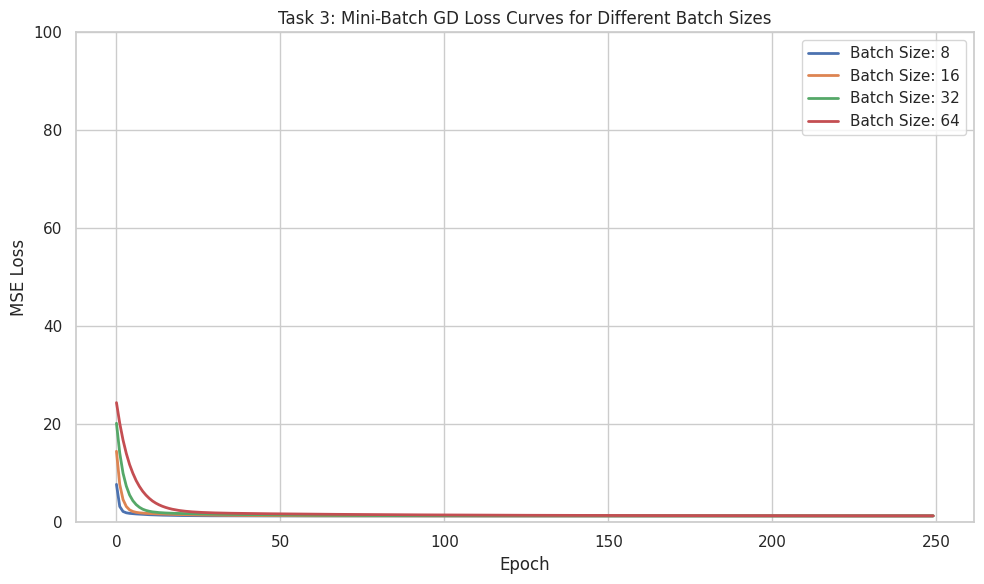

,Batch Size,Final MSE,Epochs to Converge,Training Time (s)
1,16,1.291821,45,0.193924
2,32,1.292398,86,0.153484
0,8,1.292779,23,0.244725
3,64,1.310937,155,0.130226


In [13]:
# -----------------------------
# Task 3 starter template
# -----------------------------
batch_sizes = [8, 16, 32, 64]
mbgd_histories = {}
mbgd_metrics = []

# Reuse the polynomial dataset from the tutorial's poly-data-generation cell
X_t3 = X_poly_design
y_t3 = y_poly

print(f"Using polynomial dataset with shape: {X_t3.shape}")

# Consistent learning rate and epochs for comparison
mbgd_lr = 0.02
mbgd_epochs = 250

for bs in batch_sizes:
    print(f"Training Mini-Batch GD with batch size: {bs}")
    mbgd_model = GradientDescentRegressor(method="mini-batch", lr=mbgd_lr, epochs=mbgd_epochs, batch_size=bs, random_state=42)
    mbgd_model.fit(X_t3, y_t3)
    mbgd_histories[bs] = mbgd_model.loss_history

    y_pred_t3 = mbgd_model.predict(X_t3)
    final_mse = mean_squared_error(y_t3, y_pred_t3)

    # Convergence criterion example: first epoch where loss <= 1.05 * final loss
    final_loss = mbgd_model.loss_history[-1]
    threshold = 1.05 * final_loss
    epochs_to_converge = next((i + 1 for i, l in enumerate(mbgd_model.loss_history) if l <= threshold), mbgd_model.epochs)

    mbgd_metrics.append({
        "Batch Size": bs,
        "Final MSE": final_mse,
        "Epochs to Converge": epochs_to_converge,
        "Training Time (s)": mbgd_model.training_time
    })

# Plot loss curves
plt.figure(figsize=(10, 6))
for bs, history in mbgd_histories.items():
    plt.plot(history, label=f'Batch Size: {bs}', linewidth=2)

plt.title("Task 3: Mini-Batch GD Loss Curves for Different Batch Sizes")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.ylim(0, 100) # Limit y-axis for better visualization
plt.tight_layout()
plt.show()

# Display metric table
mbgd_results_df = pd.DataFrame(mbgd_metrics)
display(mbgd_results_df.sort_values("Final MSE"))


## Task 4 (25 points)
**Compare Batch, SGD, and Mini-Batch GD** on the same polynomial regression dataset.

### Required comparison outputs
- Final MSE
- Number of epochs to converge
- Training time
- Final fitted curve quality (visual inspection)

Present a summary table and at least one comparison plot.

Using polynomial dataset with shape: (300, 4)
Training Batch GD for comparison...
Training SGD for comparison...
Training Mini-Batch GD for comparison...


,Method,Final MSE,Epochs to Converge,Training Time (s)
1,SGD,1.291670,58,0.674291
2,Mini-Batch GD,1.291821,45,0.167095
0,Batch GD,1.424179,195,0.127545


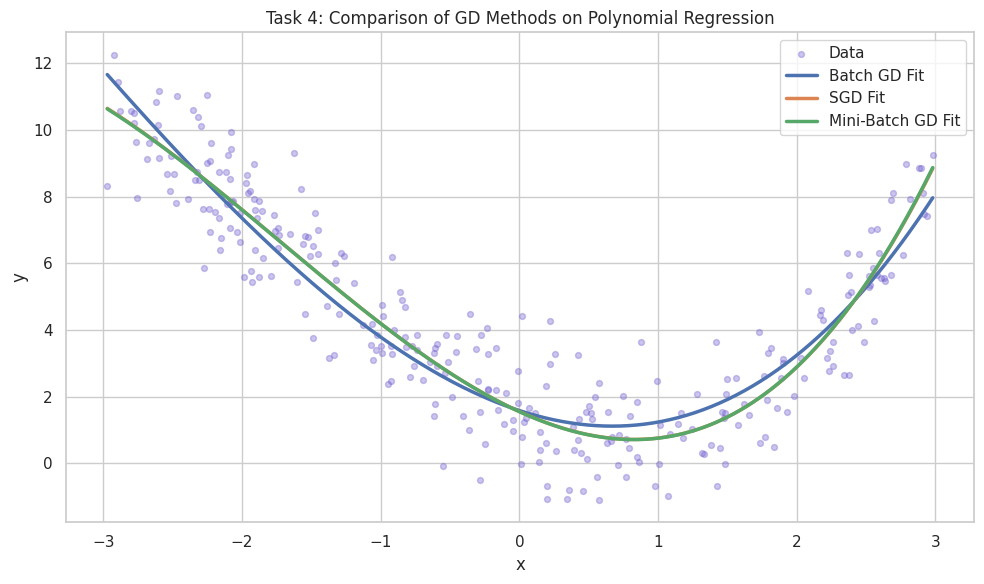

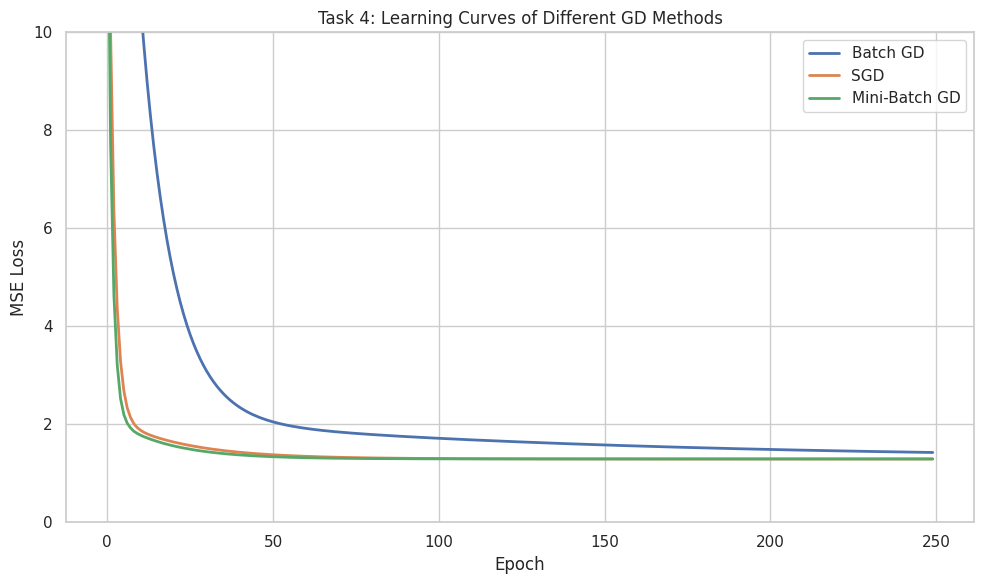

In [14]:
# -----------------------------
# Task 4 starter template
# -----------------------------
# Use the same polynomial dataset and preprocessing from the tutorial's poly-data-generation cell
X_t4 = X_poly_design
y_t4 = y_poly

print(f"Using polynomial dataset with shape: {X_t4.shape}")

# Define models with appropriate hyperparameters based on previous observations
# Adjust learning rates and epochs as needed for good convergence
task4_models = {
    "Batch GD": GradientDescentRegressor(method="batch", lr=0.05, epochs=250, random_state=42),
    "SGD": GradientDescentRegressor(method="sgd", lr=0.001, epochs=250, random_state=42), # A good LR from Task 2
    "Mini-Batch GD": GradientDescentRegressor(method="mini-batch", lr=0.02, epochs=250, batch_size=16, random_state=42) # A good BS and LR from Task 3
}

task4_rows = []
for name, model in task4_models.items():
    print(f"Training {name} for comparison...")
    model.fit(X_t4, y_t4)
    y_pred = model.predict(X_t4)

    final_mse = mean_squared_error(y_t4, y_pred)
    # Convergence criterion example: first epoch where loss <= 1.05 * final loss
    final_loss = model.loss_history[-1]
    threshold = 1.05 * final_loss
    epochs_to_converge = next((i + 1 for i, l in enumerate(model.loss_history) if l <= threshold), model.epochs)

    task4_rows.append({
        "Method": name,
        "Final MSE": final_mse,
        "Epochs to Converge": epochs_to_converge,
        "Training Time (s)": model.training_time
    })

# Build summary table
summary_df = pd.DataFrame(task4_rows)
display(summary_df.sort_values("Final MSE"))

# Plot fitted curves on the same graph for qualitative comparison.
x_grid = np.linspace(x_poly.min(), x_poly.max(), 400).reshape(-1, 1)
X_grid_raw = poly.transform(x_grid)
X_grid_scaled = scaler.transform(X_grid_raw)
X_grid_design = np.c_[np.ones((X_grid_scaled.shape[0], 1)), X_grid_scaled]

plt.figure(figsize=(10, 6))
plt.scatter(x_poly, y_poly, alpha=0.35, s=18, label="Data", color="slateblue")

for name, model in task4_models.items():
    y_grid_pred = model.predict(X_grid_design)
    plt.plot(x_grid, y_grid_pred, linewidth=2.5, label=f"{name} Fit")

plt.title("Task 4: Comparison of GD Methods on Polynomial Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

# Also plot learning curves for comparison
plt.figure(figsize=(10, 6))
for name, model in task4_models.items():
    plt.plot(model.loss_history, linewidth=2, label=name)

plt.title("Task 4: Learning Curves of Different GD Methods")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.ylim(0, 10) # Adjust as needed based on observed losses
plt.tight_layout()
plt.show()

# 5) Bonus Questions (Theoretical - 10 points)

Answer the following conceptual questions in your own words.

### 1) (4 points)
**Explain the bias-variance tradeoff in the context of choosing the degree of the polynomial. What happens if the degree is too low or too high?**

**Your answer:**

The **bias-variance tradeoff** is a fundamental concept in machine learning that describes the conflict in trying to simultaneously minimize two sources of error that prevent supervised learning algorithms from generalizing beyond their training data:

*   **Bias:** This refers to the error introduced by approximating a real-world problem, which may be complex, by a simplified model. High bias means the model is too simple (underfitting) and cannot capture the underlying patterns in the data, leading to consistent errors on both training and test data.
*   **Variance:** This refers to the algorithm's sensitivity to small fluctuations in the training data. High variance means the model is too complex (overfitting) and learns the noise in the training data rather than the intended patterns. This leads to very good performance on the training data but poor performance on unseen test data.

In the context of **polynomial regression and choosing the degree of the polynomial**:

*   **Degree is too low (High Bias / Underfitting):** If the polynomial degree is too low (e.g., a linear model for a cubic relationship), the model is too simple. It cannot capture the non-linear structure of the data. This results in **high bias**—the model consistently misses the true relationship, leading to poor performance on both training and test sets. The model is said to be **underfitting** the data.

*   **Degree is too high (High Variance / Overfitting):** If the polynomial degree is too high (e.g., a 10th-degree polynomial for a quadratic relationship), the model becomes overly complex and flexible. It starts to fit not just the underlying pattern but also the random noise present in the training data. This results in **high variance**—the model performs extremely well on the training data but fails to generalize to new, unseen data, showing poor performance on the test set. The model is said to be **overfitting** the data.

The goal is to find a polynomial degree that balances bias and variance, achieving a good fit to the training data while also generalizing well to new data. This typically means finding a degree that is complex enough to capture the true underlying pattern but not so complex that it starts memorizing noise.

### 2) (3 points)
**Why does Stochastic Gradient Descent have higher variance in parameter updates compared to Batch Gradient Descent? How does Mini-Batch GD try to balance this?**

**Your answer:**

**Stochastic Gradient Descent (SGD) has higher variance in parameter updates compared to Batch Gradient Descent (BGD) because:**

*   **BGD** calculates the gradient of the cost function using the *entire training dataset* for each parameter update. This provides a very accurate and stable estimate of the true gradient direction. As a result, the updates to the parameters ($	heta$) are consistent and directly move towards the global minimum (for convex cost functions).
*   **SGD**, on the other hand, calculates the gradient and updates parameters using *only one randomly selected training example* at each step. Because each update is based on just a single sample, the gradient estimate is noisy and highly variable. Each update might not directly point towards the global minimum but rather zigzags towards it. This inherent randomness causes the parameter updates to have high variance.

**How Mini-Batch GD tries to balance this:**

**Mini-Batch Gradient Descent (MBGD)** strikes a balance between BGD and SGD by computing the gradient and updating parameters using a *small, randomly selected subset (mini-batch)* of the training data at each step. Here's how it balances the variance:

*   **Reduced Variance compared to SGD:** By using a mini-batch (e.g., 32, 64, 128 samples) instead of just one sample, the gradient estimate becomes more stable and less noisy than in pure SGD. The average gradient over a small batch is a better approximation of the true gradient than the gradient from a single sample. This reduces the variance of the parameter updates, leading to a smoother and more stable convergence path.
*   **Faster and Less Redundant than BGD:** While BGD's updates are very stable, they are computationally expensive, especially for large datasets, as it processes the entire dataset for each update. MBGD computes gradients on a smaller batch, which is faster per update than BGD. It also introduces enough noise to potentially escape shallow local minima, a benefit sometimes observed in SGD.

In essence, MBGD leverages the computational efficiency of working with smaller subsets (like SGD) while obtaining a more reliable gradient estimate (approaching BGD's stability) to achieve a good balance of convergence speed, stability, and avoidance of local minima.

### 3) (3 points)
**Discuss the importance of feature scaling when using Gradient Descent for polynomial regression. What problems can arise without scaling?**

**Your answer:**

**Feature scaling is critically important when using Gradient Descent for polynomial regression due to several reasons:**

1.  **Unequal Scales of Features:** In polynomial regression, features are created as powers of the original input ($x, x^2, x^3, 	ext{etc.}$). If the original $x$ values have a wide range (e.g., from -100 to 100), then $x^2$ will range from 0 to 10,000, $x^3$ from -1,000,000 to 1,000,000, and so on. These vastly different scales mean that the partial derivatives of the cost function with respect to the coefficients of higher-degree terms will be much larger than those for lower-degree terms. Gradient descent updates are proportional to these gradients.

2.  **Impact on Convergence Speed and Stability:**
    *   **Slow Convergence:** Without scaling, the cost function surface can become very elongated and narrow (like an ellipse or a long valley). If the learning rate is set too low to accommodate the largest gradients (from higher-degree terms), the optimization will take many small steps and converge very slowly along the dimensions with smaller gradients. Conversely, if the learning rate is set too high for the smaller gradients, it might cause overshooting and divergence along the dimensions with larger gradients.
    *   **Oscillations and Divergence:** When features are not scaled, the optimizer might oscillate back and forth across the narrow parts of the cost function, making slow progress towards the minimum. In extreme cases, if the learning rate is not carefully chosen, the oscillations can grow, leading to divergence where the loss increases rapidly and the parameters become `NaN` or `inf`.

3.  **Numerical Stability:** Large differences in feature magnitudes can lead to numerical instability, especially when dealing with floating-point arithmetic. Computations involving very large and very small numbers simultaneously can result in precision errors, underflow, or overflow, hindering the optimization process.

**What problems can arise without scaling?**

*   **Difficulty in choosing a learning rate:** It becomes much harder to find a single learning rate that works well across all features. A learning rate that's good for one feature might be too small for another (leading to slow convergence) or too large (leading to divergence or oscillations).
*   **Slow convergence:** The algorithm will take much longer to reach the minimum, as it has to navigate a highly distorted cost landscape.
*   **Overshooting and oscillations:** Gradient descent steps can be too large in some directions and too small in others, causing the optimizer to bounce around the minimum without settling.
*   **Divergence:** The model parameters can diverge, meaning the loss function increases indefinitely, often resulting in `NaN` values for parameters or loss.
*   **Suboptimal solutions:** The algorithm might get stuck in a suboptimal region or fail to converge to the true minimum within a reasonable number of epochs.

By scaling features (e.g., using `StandardScaler` to bring them to a mean of 0 and standard deviation of 1), all features contribute more equally to the gradient updates. This makes the cost function surface more spherical or isotropic, allowing gradient descent to take more direct paths to the minimum, converge faster, and be more robust to the choice of learning rate.

# 6) Conclusion

In this lab, you:
- Implemented **Batch GD**, **SGD**, and **Mini-Batch GD** from scratch using NumPy.
- Compared optimization behavior through loss curves and empirical metrics.
- Applied gradient descent methods to **polynomial regression** with feature engineering.
- Explored practical tuning effects of learning rate and batch size.

Key takeaway: there is no single universally best optimizer setup. Effective training depends on balancing learning rate, batch size, feature scaling, and computational constraints.